In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway


In [2]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
import xarray as xr

from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
from models.model import CNN_Model, CNN_Model_ChannelAttention, CNN_Model_SpatialAttention
import pandas as pd
from torch import nn
from lightning.pytorch import loggers, seed_everything
from models.lightning import LitCNN_regression, AttributableTrainer
# from models.losses import get_loss
import matplotlib
from models.data import get_input_data_from_wandb_logger,get_input_data_from_wandb_logger_three_types
# from models.model import get_model
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
plt.style.use('robin')
# matplotlib.use('tkagg')
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
import seaborn as sns 
import argparse
from tqdm.notebook import tqdm
import cartopy.crs as ccrs
import xbatcher as xb
import dask
import xbatcher
import xbatcher.loaders.torch

Running imports...


Seed set to 42


In [3]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker

def clean_map_ax(ax, boundaries=(-90, 50, 0, 90), gl=True):
    lon_min, lon_max , lat_min, lat_max = boundaries

    ax.coastlines( color='.5',linewidths=.3)
    # ax.set_extent((-60,60,0,80))
    ax.set_extent(boundaries, crs=ccrs.PlateCarree())
    
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    if gl:
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(-180,180,17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        
    longitudes = np.linspace(lon_min, lon_max, 100)
    latitudes = np.linspace(lat_min, lat_max,100)
    xx = list(longitudes)[::-1]+\
            [longitudes.min() for _ in range(latitudes.size)] + \
                list(longitudes)+\
                    [longitudes.max() for _ in range(latitudes.size)]
    yy = [latitudes.max() for _ in range(longitudes.size)] \
            + list(latitudes)[::-1]+\
                [latitudes.min() for _ in range(longitudes.size)]+ \
                    list(latitudes)[::-1]
    verts = np.array([xx, yy]).T
    circle = Path(verts)
    ax.set_boundary(circle, transform=ccrs.PlateCarree())

In [4]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


In [5]:
ds = xr.open_zarr('/Data/gfi/users/rogui7909/data/ERA5/u850_inputs_day_361x720.zarr')
ds

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 34GB
Dimensions:      (time: 16436, longitude: 720, latitude: 361, var_name: 1)
Coordinates:
  * time         (time) datetime64[ns] 131kB 1979-01-01 ... 2023-12-31
  * longitude    (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
  * latitude     (latitude) float32 1kB 90.0 89.5 89.0 ... -89.0 -89.5 -90.0
  * var_name     (var_name) object 8B 'u850'
Data variables:
    std_value    (var_name, latitude, longitude) float64 2MB dask.array<chunksize=(1, 361, 720), meta=np.ndarray>
    data_normed  (time, var_name, latitude, longitude) float64 34GB dask.array<chunksize=(128, 1, 361, 720), meta=np.ndarray>
    mean_value   (var_name, latitude, longitude) float64 2MB dask.array<chunksize=(1, 361, 720), meta=np.ndarray>

In [6]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

train_loader, val_loader, test_loader, ds_test = get_input_data_from_wandb_logger_three_types(wandb_logger, lon_lim=(-128, 53), add_noise=False, noise_scale=5, noisy_samples=5)

callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,)

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_timesteps_predicted']*3
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variables'])

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready:
    Image size: 65703 (363x181)
    Input data: u850
    4 Predicted timesteps for future rainfall
    90th percentile predicted


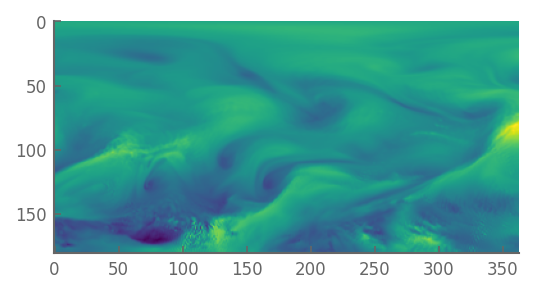

In [6]:
plt.imshow(train_loader.dataset[0][0][0][0])

In [7]:
class CNN_Model_2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=4,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_2, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.number_conv_layers = number_conv_layers
        self.conv_layer1 = nn.Sequential(
                                     nn.Conv2d(input_channels, 
                                     out_channels_conv1, 
                                     kernel_size=size_conv_kernel, 
                                     stride=1, padding=(size_conv_kernel-1)//2),
                            nn.MaxPool2d(kernel_size=2, stride=2),
                            nn.ReLU())
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer5 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                          kernel_size=size_conv_kernel, 
                                          stride=1, padding=(size_conv_kernel-1)//2),
                                nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer6 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                            out_channels_conv1*out_channel_factor_increase_per_layer**5, 
                                            kernel_size=size_conv_kernel, 
                                            stride=1, padding=1),
                                nn.MaxPool2d(kernel_size=(1,2), stride=2),
                                nn.ReLU())
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        elif number_conv_layers == 5:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
        elif number_conv_layers == 6:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        if self.number_conv_layers == 0:
            self.linear_size = image_size 
        else:
            self.linear_size = image_size * self.output_cnn_channels // max_pools 
        if self.number_conv_layers == 6:
            self.linear_size = self.linear_size*2
        if self.number_conv_layers == 0:
            self.linear_size = image_size*2 
        self.fc1 = nn.Linear(self.linear_size, 512)
        self.fc2 = nn.Linear(512, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        print(self.linear_size)
        if self.number_conv_layers>0:
            cnn_out = self.cnn(x)
        else:
            cnn_out = x
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
        output = self.fc2(output)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        
NN = CNN_Model_2(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=5,
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
NN(train_loader.dataset[0][0]).shape


16425


RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x14080 and 16425x512)

In [7]:
class CNN_Model_higres(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=4,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_higres, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.number_conv_layers = number_conv_layers
        self.conv_layer1 = nn.Sequential(
                                     nn.Conv2d(input_channels, 
                                     out_channels_conv1, 
                                     kernel_size=size_conv_kernel, 
                                     stride=2, padding=(size_conv_kernel-1)//2),
                            # nn.MaxPool2d(kernel_size=2, stride=2),
                            nn.ReLU())
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer5 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer6 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                            out_channels_conv1*out_channel_factor_increase_per_layer**5, 
                                            kernel_size=size_conv_kernel, 
                                            stride=2, padding=1),
                                # nn.MaxPool2d(kernel_size=(2,2), stride=2),
                                nn.ReLU())
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        elif number_conv_layers == 5:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
        elif number_conv_layers == 6:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        if self.number_conv_layers == 0:
            self.linear_size = image_size 
        else:
            self.linear_size = image_size * self.output_cnn_channels // max_pools 
        if self.number_conv_layers == 6:
            self.linear_size = 9216
        if self.number_conv_layers == 0:
            self.linear_size = image_size*2 
        self.fc1 = nn.Linear(self.linear_size, 512)
        self.fc2 = nn.Linear(512, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        if self.number_conv_layers>0:
            cnn_out = self.cnn(x)
        else:
            cnn_out = x
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
        output = self.fc2(output)
        
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        
NN = CNN_Model_higres(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=6,
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 

NN(train_loader.dataset[0][0][:2])


tensor([[0.4907, 0.2583, 0.2509, 0.5072, 0.2452, 0.2476, 0.4938, 0.2591, 0.2471,
         0.4896, 0.2553, 0.2551],
        [0.4904, 0.2585, 0.2511, 0.5075, 0.2452, 0.2473, 0.4939, 0.2591, 0.2470,
         0.4895, 0.2554, 0.2552]], grad_fn=<ViewBackward0>)

In [ ]:
class CNN_Model_linus(nn.Module):
    def __init__(self, 
                 input_channels, 
                 image_size, 
                 num_timesteps,
                 number_conv_layers=4,
                 size_conv_kernel=3,
                 out_channels_conv1=12, 
                 out_channel_factor_increase_per_layer = 2,
                 ):
        super(CNN_Model_linus, self).__init__()
        
        # CNN layers to extract spatial features
        # self.sigmoid = sigmoid
        # self.softmax = softmax
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
        self.number_conv_layers = number_conv_layers
        self.conv_layer1 = nn.Sequential(
                                     nn.Conv2d(input_channels, 
                                     out_channels_conv1, 
                                     kernel_size=size_conv_kernel, 
                                     stride=2, padding=(size_conv_kernel-1)//2),
                            # nn.MaxPool2d(kernel_size=2, stride=2),
                            nn.ReLU())
        self.conv_layer2 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer3 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer4 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer5 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
                                          out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                          kernel_size=size_conv_kernel, 
                                          stride=2, padding=(size_conv_kernel-1)//2),
                                # nn.MaxPool2d(kernel_size=2, stride=2),
                                nn.ReLU())
        self.conv_layer6 = nn.Sequential(
                                nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
                                            out_channels_conv1*out_channel_factor_increase_per_layer**5, 
                                            kernel_size=size_conv_kernel, 
                                            stride=1, padding=1),
                                # nn.MaxPool2d(kernel_size=(1,2), stride=2),
                                nn.ReLU())
        
        if number_conv_layers == 1:
            self.cnn = nn.Sequential(self.conv_layer1)
        elif number_conv_layers == 2:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
        elif number_conv_layers == 3:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
        elif number_conv_layers == 4:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
        elif number_conv_layers == 5:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
        elif number_conv_layers == 6:
            self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
        max_pools = 4**(number_conv_layers)
        self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
        if self.number_conv_layers == 0:
            self.linear_size = image_size 
        else:
            self.linear_size = image_size * self.output_cnn_channels // max_pools 
        if self.number_conv_layers == 6:
            self.linear_size = self.linear_size*2
        if self.number_conv_layers == 0:
            self.linear_size = image_size*2 
        self.fc1 = nn.Linear(self.linear_size, 512)
        self.fc2 = nn.Linear(512, self.num_classes)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size,  channels, height, width = x.size()
        if self.number_conv_layers>0:
            cnn_out = self.cnn(x)
        else:
            cnn_out = x
        cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
        output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
        output = self.fc2(output)
        output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
        output = torch.sigmoid(output) 
        X1 = output[:,:,0]
        X2 = output[:,:,1]
        P_norain = X1 
        P_rain = (1-X1)*(1-X2)
        P_extreme = (1-X1)*X2
        output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
        return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)
        
NN = CNN_Model_linus(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
NN(train_loader.dataset[0][0]).shape


RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x30976 and 32851x512)

In [8]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, patch_size, emb_dim):
        super().__init__()
        self.patch_size = patch_size
        self.emb_dim = emb_dim
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

        self.pos_embed = None  # We'll create this dynamically

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, emb_dim, H/P, W/P)
        B, D, Hp, Wp = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, N, D) where N = Hp * Wp

        # Create positional embeddings dynamically
        if self.pos_embed is None or self.pos_embed.shape[1] != x.shape[1]:
            self.pos_embed = nn.Parameter(torch.randn(1, x.shape[1], self.emb_dim, device=x.device))

        x = x + self.pos_embed
        return x  # (B, N, D)

class ViT_Model(nn.Module):
    def __init__(self, 
                 input_channels, 
                 num_timesteps,
                 patch_size=4,
                 emb_dim=128,
                 num_layers=6,
                 num_heads=8,
                 mlp_dim=256,
                 dropout=0.1):
        super().__init__()
        self.num_timesteps = num_timesteps
        self.classes_per_timestep = 3
        self.num_classes = self.num_timesteps * (self.classes_per_timestep - 1)

        self.patch_embed = PatchEmbedding(input_channels, patch_size, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=num_heads,
                                                   dim_feedforward=mlp_dim, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(emb_dim)

        self.mlp_head = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Linear(512, self.num_classes)
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.patch_embed(x)      # (B, N, D)
        x = self.transformer(x)      # (B, N, D)
        x = self.norm(x.mean(dim=1)) # (B, D), mean pooling
        x = self.mlp_head(x)         # (B, num_classes)
        
        x = x.view(-1, self.num_timesteps, self.classes_per_timestep - 1)
        x = torch.sigmoid(x)

        X1 = x[:, :, 0]
        X2 = x[:, :, 1]
        P_norain = X1
        P_rain = (1 - X1) * (1 - X2)
        P_extreme = (1 - X1) * X2
        out = torch.stack([P_norain, P_rain, P_extreme], dim=2)

        return out.view(-1, self.num_timesteps * self.classes_per_timestep)


NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               patch_size=16,
               )
 
NN(train_loader.dataset[0][0])


tensor([[0.6201, 0.1806, 0.1993,  ..., 0.4441, 0.2623, 0.2935],
        [0.6104, 0.1950, 0.1946,  ..., 0.4325, 0.2626, 0.3049],
        [0.6181, 0.1973, 0.1846,  ..., 0.4296, 0.2598, 0.3106],
        ...,
        [0.5992, 0.2096, 0.1912,  ..., 0.4361, 0.2502, 0.3137],
        [0.6126, 0.1962, 0.1912,  ..., 0.4420, 0.2546, 0.3034],
        [0.6144, 0.1969, 0.1886,  ..., 0.4350, 0.2614, 0.3035]],
       grad_fn=<ViewBackward0>)

In [8]:
# NN = CNN_Model_linus(input_channels = wandb_logger.experiment.config['num_channels'], 
#                image_size=wandb_logger.experiment.config['image_size'], 
#                num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
#                number_conv_layers=wandb_logger.experiment.config['num_conv_layer'],
#                size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
#                out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
#                out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 
# NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
#                num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
#                )
# NN = ViT_Model(input_channels = wandb_logger.experiment.config['num_channels'], 
#                num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
#                patch_size=16,
#                )
NN = CNN_Model_higres(input_channels = wandb_logger.experiment.config['num_channels'], 
               image_size=wandb_logger.experiment.config['image_size'], 
               num_timesteps=wandb_logger.experiment.config['num_timesteps_predicted'],
               number_conv_layers=6,
               size_conv_kernel=wandb_logger.experiment.config['size_conv_kernel'],
               out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'], 
               out_channel_factor_increase_per_layer = wandb_logger.experiment.config['factor_increase_kernels_per_conv_layer'],)
 

class MultiCrossEntropyLoss(nn.Module):
    def __init__(self, timesteps):
        super(MultiCrossEntropyLoss, self).__init__()
        self.nll = torch.nn.NLLLoss(weight = torch.Tensor([1,1,9]))
        self.timesteps = timesteps
        
    def forward(self, pred, target):
        """
        Computes the loss for the given prediction.
        """
        loss = []
        pred = pred.view(-1, self.timesteps, 3)
        proba = torch.softmax(pred, dim=2)
        for k,timestep in enumerate(range(self.timesteps)):
            res = self.nll(torch.log(proba[:,timestep]), target[:,timestep])
            loss.append(res)#*(k+1)/10)
        loss = torch.mean(torch.stack(loss))
        return loss
    

loss = MultiCrossEntropyLoss(timesteps = wandb_logger.experiment.config['num_timesteps_predicted'])


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)


In [9]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                  | Params | Mode 
----------------------------------------------------------
0 | model   | CNN_Model_higres      | 6.3 M  | train
1 | loss_fn | MultiCrossEntropyLoss | 0      | train
----------------------------------------------------------
6.3 M     Trainable params
0         Non-trainable params
6.3 M     Total params
25.183    Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [10]:
model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=val_loader)
wandb.finish()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.9644057750701904     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
test/loss,▁
train/loss,█████▇██▇▇▆▇▇▆▇▅▆▄▄▅▅▃▂▄▅▄▃▄▅▃▃▅▁▄▃▂▁▃▂▃
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
val/loss,█▆▄▃▁▁▁▁▂▂
epoch,10
test/loss,0.96441
train/loss,0.90944
trainer/global_step,360
val/loss,0.96441


In [11]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3).cpu().numpy()
# preds = torch.argmax(y_scores, dim=2)
# targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test, timestep=np.arange(y_scores.shape[1])))
# preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test, timestep=np.arange(y_scores.shape[1])))
# results = xr.Dataset(dict(targets=targets, preds=preds))
# proba=xr.DataArray(y_scores.cpu().numpy(), dims=['time','timestep','type_rain'], 
#                    coords=dict(time=ds_test.time, timestep=np.arange(y_scores.shape[1]), type_rain=['no_rain','moderate_rain','extreme_rain']))
# df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
# df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values
# # model.test_true_values

In [ ]:
y_test = torch.stack(model.test_true_values)#.cpu().numpy()
y_scores = torch.stack(model.test_pred).view(-1, wandb_logger.experiment.config['num_timesteps_predicted'], 3).cpu()
preds = torch.argmax(y_scores, dim=2)
targets=xr.DataArray(y_test.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
preds=xr.DataArray(preds.cpu().numpy(), dims=['time','timestep'], coords=dict(time=ds_test.time[:y_test.shape[0]], timestep=np.arange(y_scores.shape[1])))
results = xr.Dataset(dict(targets=targets, preds=preds))
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values
# model.test_true_values

# pred = torch.stack([corn_label_from_logits(y_scores[:,k]) for k in range(y_scores.shape[1])])

[Text(0, 0, 'D0'), Text(1, 0, 'D+1'), Text(2, 0, 'D+2'), Text(3, 0, 'D+3')]

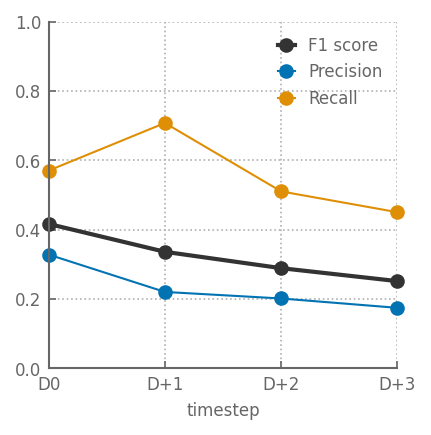

In [13]:
TP = ((preds == targets)&(targets==2)).sum('time')
recall = TP / (targets==2).sum('time')
precision = TP / (preds==2).sum('time')
f1 = 2*(precision*recall)/(precision+recall)



# recall_season.plot(hue='season')
fig, ax = plt.subplots(figsize=(3,3,))
f1.plot(color='.2', lw=2, label='F1 score', marker='o', clip_on=False)
precision.plot(label='Precision', marker='o', clip_on=False)
recall.plot(label='Recall', marker='o', clip_on=False)
plt.legend()
ax.set_ylim(0,1)
ax.grid()
ax.set_xlim(0,3)
ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['D0','D+1','D+2','D+3'])

In [14]:
df_=pd.DataFrame(dict(pred=preds.to_series(), targets=targets.to_series()))
df_['pred_time'] = (df_.index.get_level_values(0)+pd.Timedelta(1,'D')*df_.index.get_level_values(1)).values

times = df_.query("targets==2 & pred==2").groupby('pred_time').count().pred.sort_values()
events_predicted = times.loc[times>3].index
steps = 4
start_times = events_predicted -  pd.Timedelta(steps-1,'D')
print("Number of 4x events:",len(start_times))
num_extremes = df_.targets.loc[df_.targets==2].unstack().count(axis=1)
num_extremes_pred = df_.targets.where((df_.targets==2)&(df_.pred==2)).fillna(0).unstack().sum(axis=1)//2

pred_FP = df_.query("pred==2 & targets<2").groupby('pred_time').count().query("pred==4").index

start_times_FP = pred_FP - pd.Timedelta(steps-1,'D')
# events

Number of 4x events: 59


In [26]:

ds_test = ds_test.sortby('time')

In [15]:
%%time
steps = 4

from captum.attr import IntegratedGradients
method = IntegratedGradients(model.model)
all_multi_attrs = []
all_multi_sens = []

for k in tqdm(range(len(events_predicted))):
    start = start_times[k].strftime("%Y-%m-%d %H:%M:%S")
    end = events_predicted[k].strftime("%Y-%m-%d %H:%M:%S")
    # print(start,end)
    ds_test_extract = ds_test.sel(time=slice(start ,end))
    tensor_in = torch.Tensor(ds_test_extract.inputs.values)
    tensor_out = torch.Tensor(ds_test_extract.targets.values)
    attrs = method.attribute(tensor_in, baselines=torch.Tensor([0]),target=[3*(steps-k)-1 for k in range(steps)]) 
    da_attrs = xr.DataArray(attrs, dims = ['timestep','var_name','latitude','longitude'], 
                            coords= dict(timestep=np.arange(1,steps+1),var_name=ds_test_extract.var_name, latitude=ds_test_extract.latitude, longitude=ds_test_extract.longitude))
    all_multi_attrs.append(da_attrs.assign_coords(time=events_predicted[k]))
    sens = da_attrs/ds_test_extract.inputs.rename(time='timestep').assign_coords(timestep=da_attrs.timestep)
    all_multi_sens.append(sens.assign_coords(time=events_predicted[k]))
ds_attributions = xr.concat(all_multi_attrs, dim='time')
ds_sens = xr.concat(all_multi_sens, dim='time')

  0%|          | 0/59 [00:00<?, ?it/s]

CPU times: user 6min, sys: 57.3 s, total: 6min 58s
Wall time: 31.1 s


In [16]:
final_ds = xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens))
final_ds = final_ds.rename(time='attribution_time')
final_ds = xr.merge([final_ds, results.assign_coords(timestep=np.arange(1,5))])
n = wandb_logger.experiment.config['num_conv_layer']
# final_ds.to_netcdf(f'out_data/rosendal/highres_vit_16patch_attributions.nc')
# final_ds.to_netcdf('')

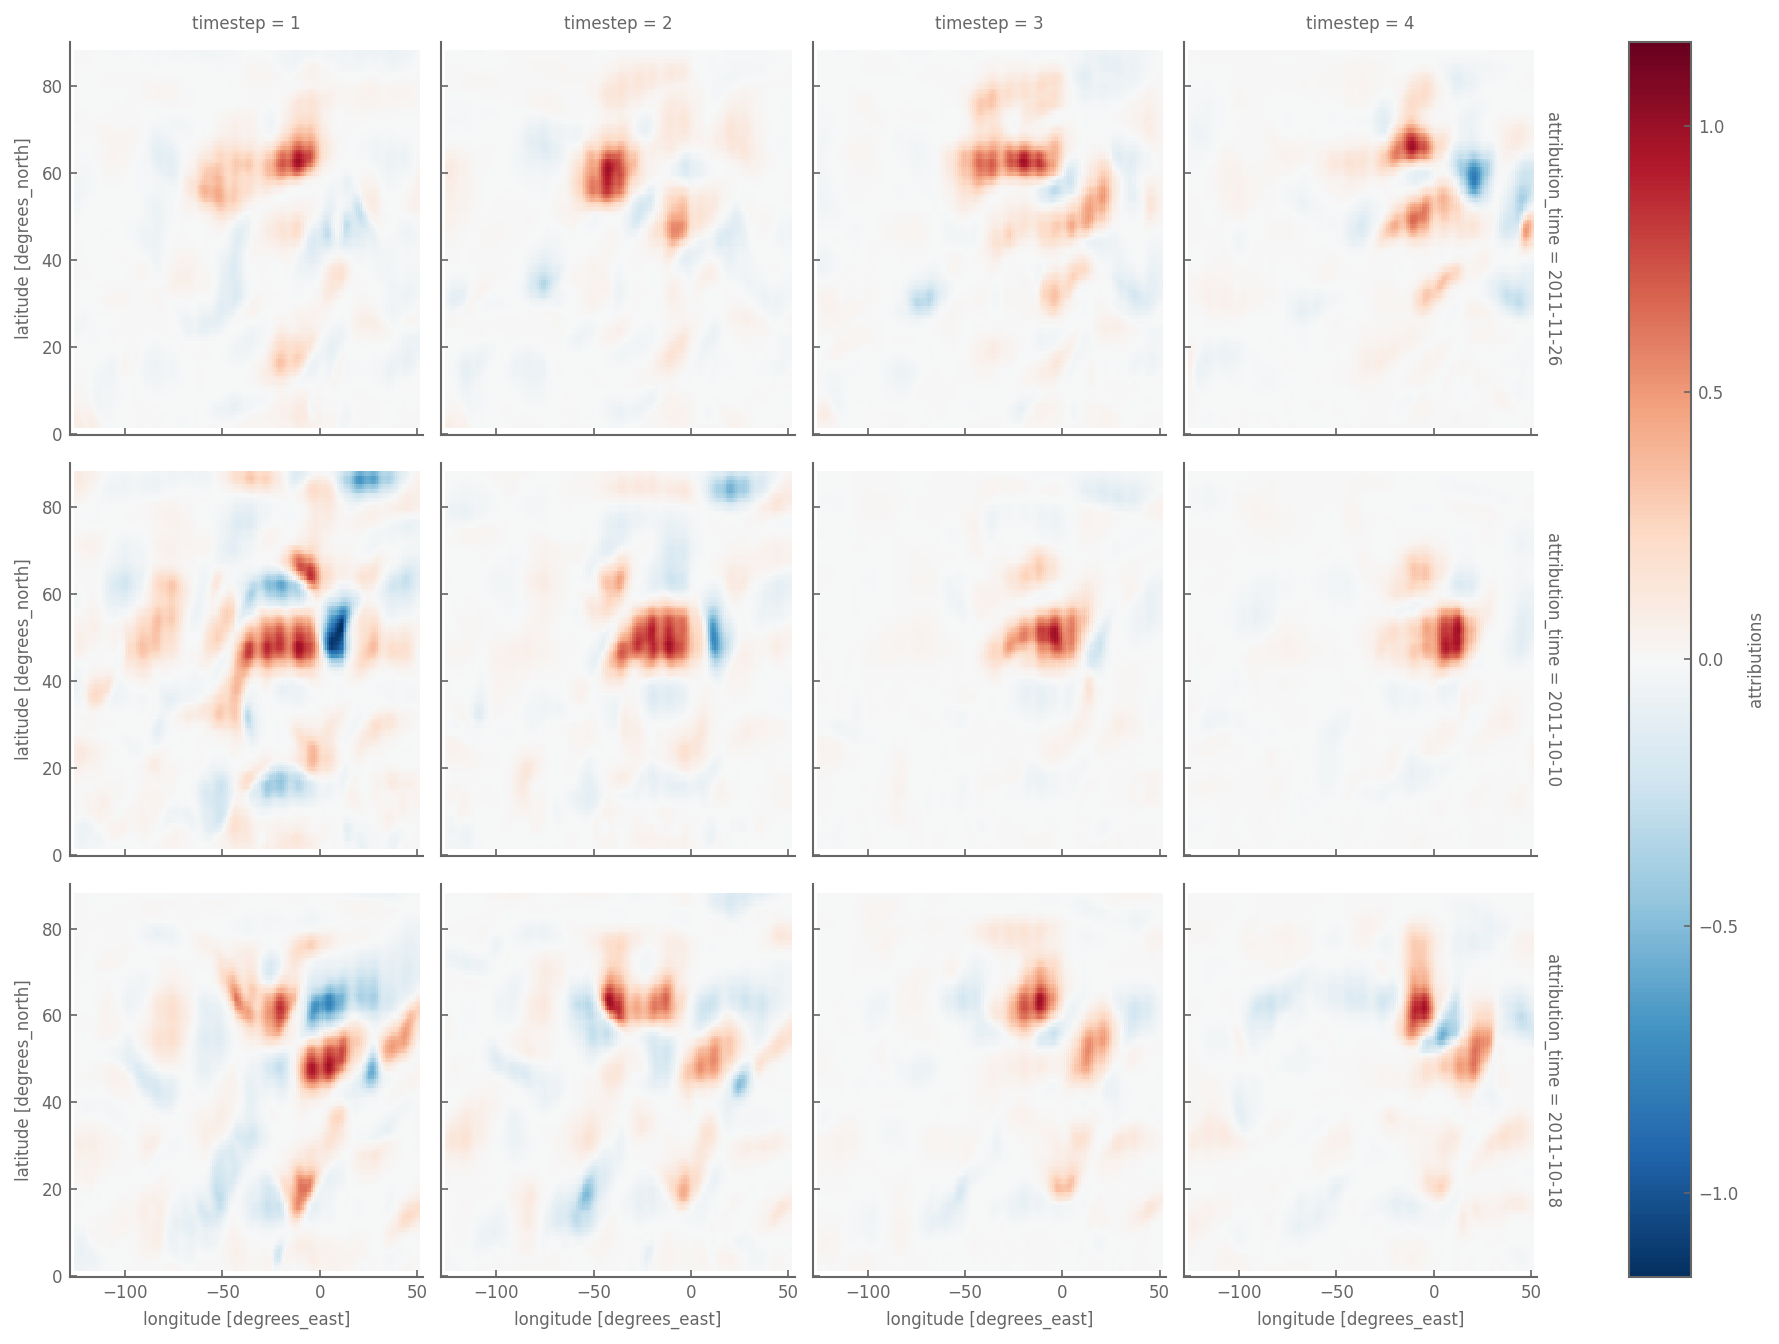

In [19]:
test = final_ds.attributions.isel(attribution_time=range(3)).rolling(longitude=8, latitude=8, center=True).mean()#.sel(longitude=slice(0,10), latitude=slice(10,0))
(test/test.max(['longitude','latitude'])).plot(col='timestep', row='attribution_time')

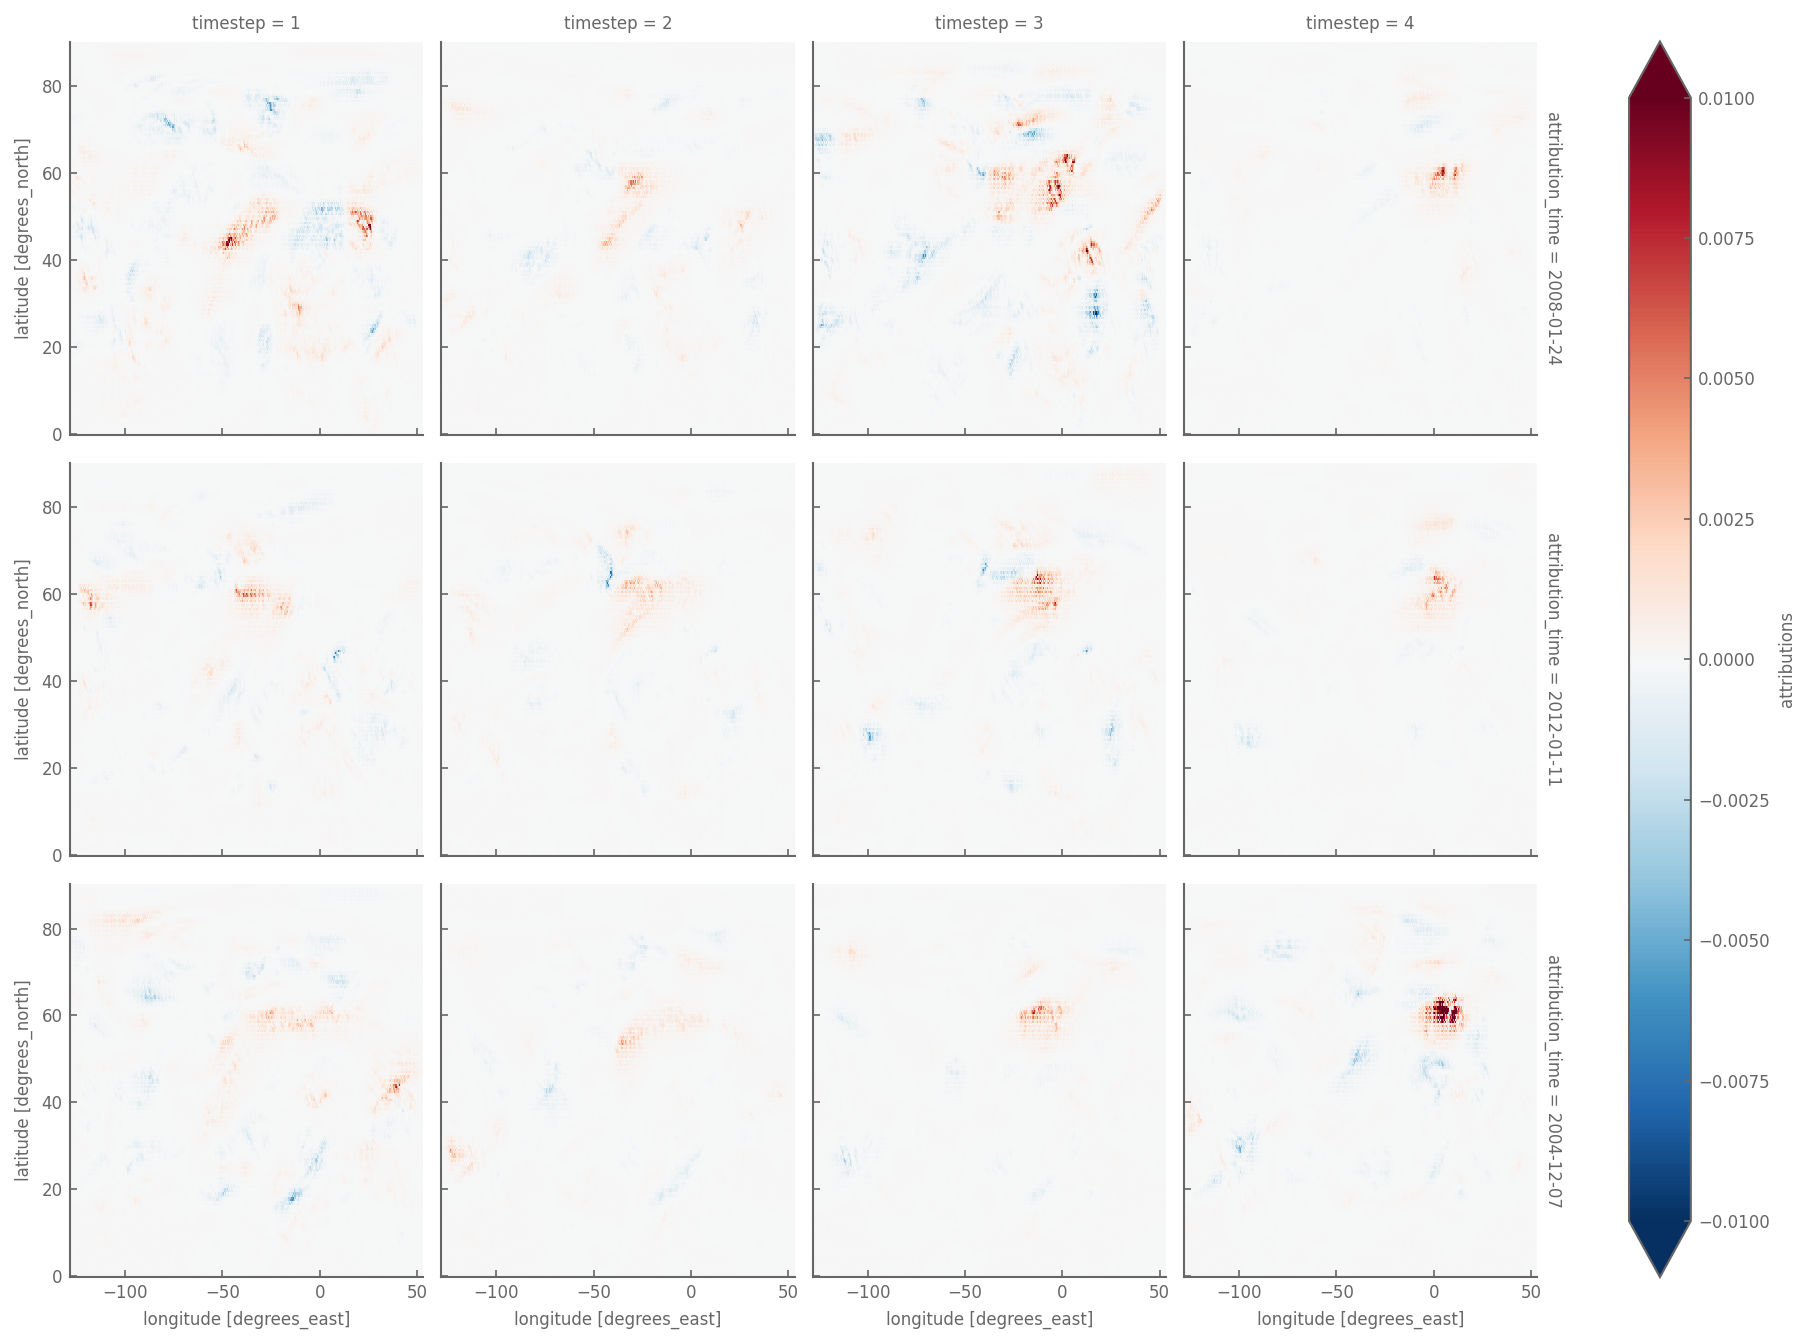

In [28]:
final_ds.attributions.isel(attribution_time=range(3)).plot(col='timestep', row='attribution_time', vmax=.01)

In [ ]:
with torch.no_grad():
    probas = model.model(train_loader.dataset[0][0])
probas[:,3].argmax()

tensor(128)

In [ ]:
# test = train_loader.dataset[0][0][449]
test = train_loader.dataset[0][0][49:50]
test.shape

out11 = model.model.conv_layer1[0](test)
out12 = model.model.conv_layer1[1](out11)
out13 = model.model.conv_layer1[2](out12)

out21 = model.model.conv_layer2[0](out13)
out22 = model.model.conv_layer2[1](out21)
out23 = model.model.conv_layer2[2](out22)

out31 = model.model.conv_layer3[0](out23)
out32 = model.model.conv_layer3[1](out31)
out33 = model.model.conv_layer3[2](out32)

out41 = model.model.conv_layer4[0](out33)
out42 = model.model.conv_layer4[1](out41)
out43 = model.model.conv_layer4[2](out42)


In [16]:
time1 = results.isel(timestep=3).where((results.isel(timestep=3).targets==2)&(results.isel(timestep=3).preds==True), drop=True).time.values
time2 = results.where((results.targets==results.preds), drop=True).time.values
time = [k for k in time1 if k in time2]
len(time)

88

In [ ]:
# time = results.isel(timestep=3).where((results.isel(timestep=3).targets==2)&(results.isel(timestep=3).preds==True), drop=True).time
data_in = ds_test.sel(time=time[10:20]).inputs
inputs = torch.Tensor(data_in.values)
out11 = model.model.conv_layer1[0](inputs)
out12 = model.model.conv_layer1[1](out11)
out13 = model.model.conv_layer1[2](out12)

out21 = model.model.conv_layer2[0](out13)
out22 = model.model.conv_layer2[1](out21)
out23 = model.model.conv_layer2[2](out22)

out31 = model.model.conv_layer3[0](out23)
out32 = model.model.conv_layer3[1](out31)
out33 = model.model.conv_layer3[2](out32)

out41 = model.model.conv_layer4[0](out33)
out42 = model.model.conv_layer4[1](out41)
out43 = model.model.conv_layer4[2](out42)

mask1 = torch.nn.functional.interpolate(out13, scale_factor=2, mode='bicubic').detach()
mask2 = torch.nn.functional.interpolate(out23, scale_factor=4, mode='bicubic').detach()
mask3 = torch.nn.functional.interpolate(out33, scale_factor=8, mode='bicubic').detach()
mask4 = torch.nn.functional.interpolate(out43, scale_factor=16, mode='bicubic').detach()

mask1 = xr.DataArray(mask1, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))
mask2 = xr.DataArray(mask2, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))
mask3 = xr.DataArray(mask3, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))
mask4 = xr.DataArray(mask4, dims=['time','filter','latitude','longitude'], coords=dict(longitude=data_in.longitude, latitude=data_in.latitude, time=data_in.time))

mask1 = mask1.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9
mask2 = mask2.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9
mask3 = mask3.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9
mask4 = mask4.stack(space=['latitude','longitude']).rank('space',pct=True).unstack()>.9

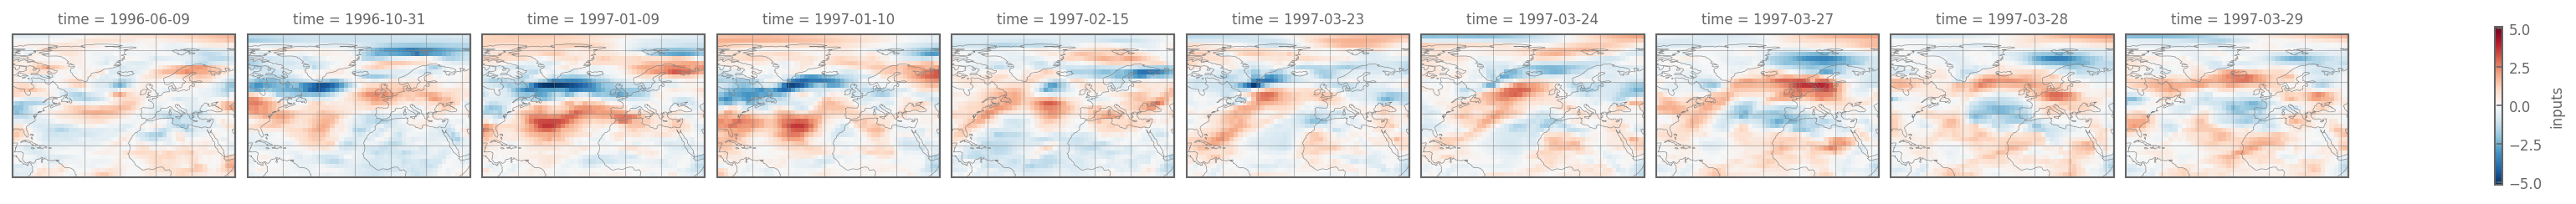

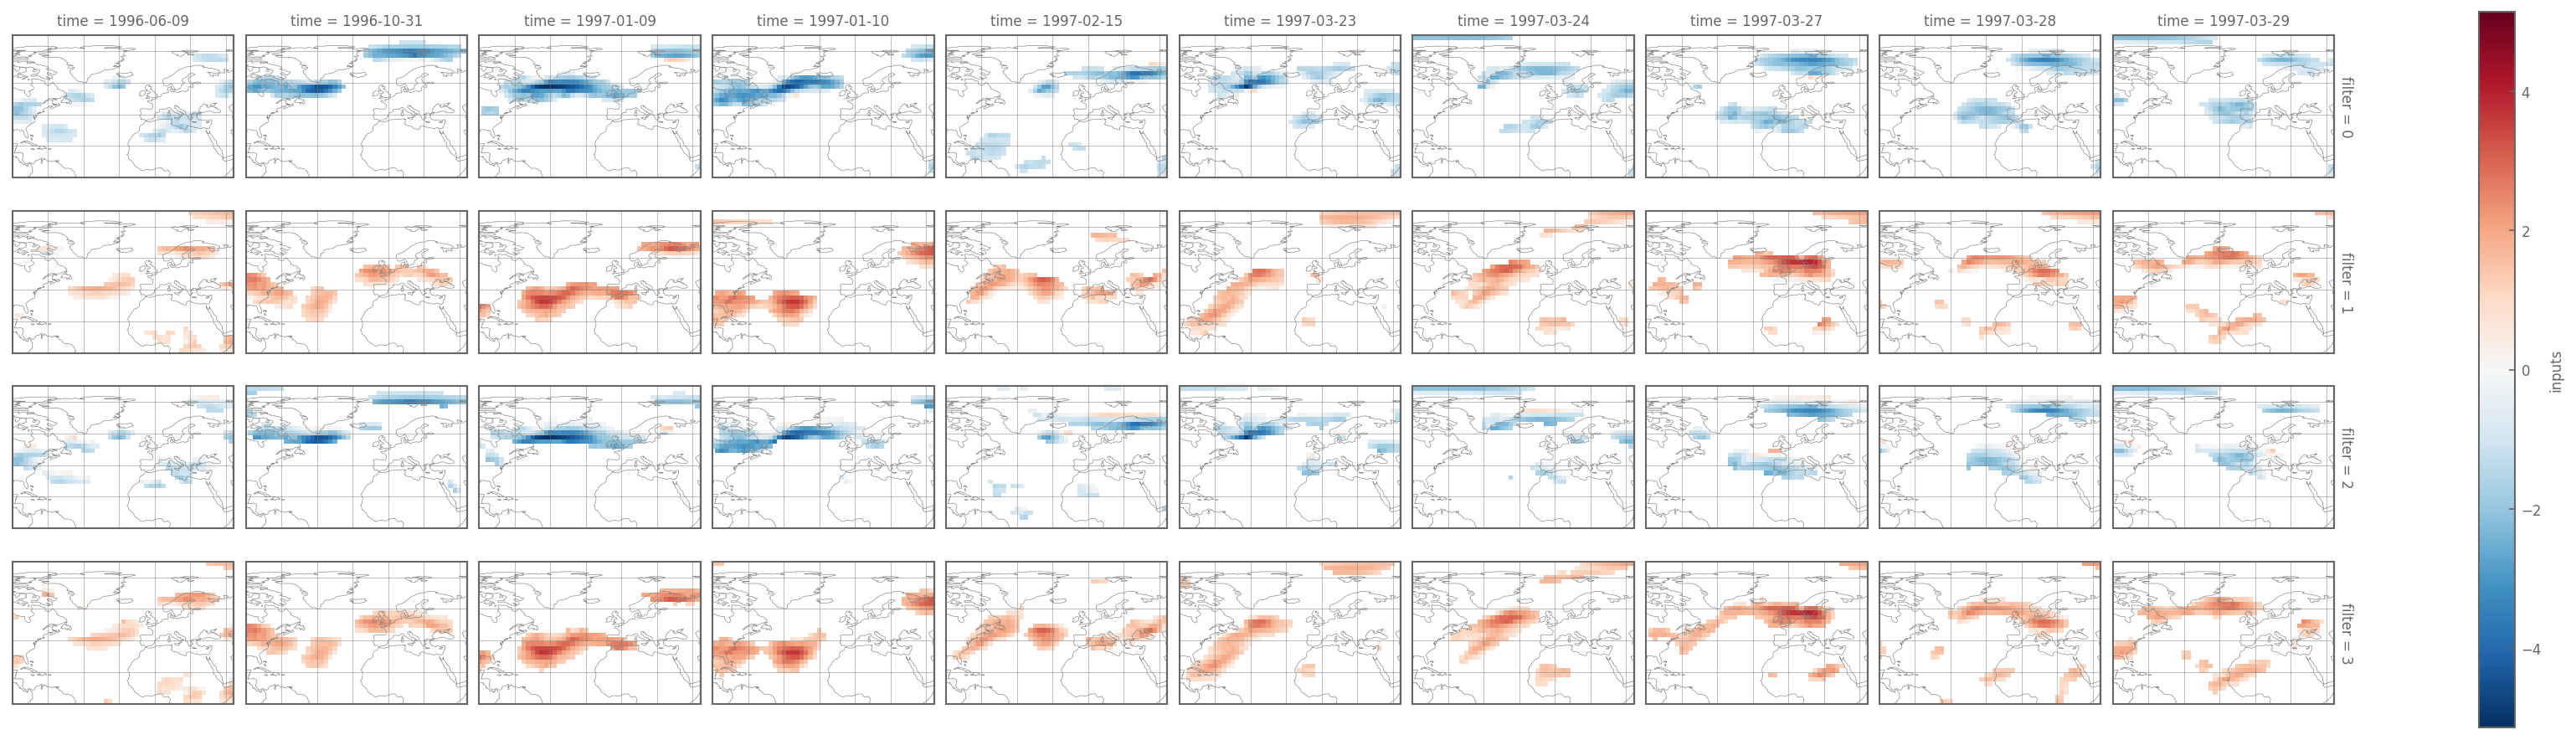

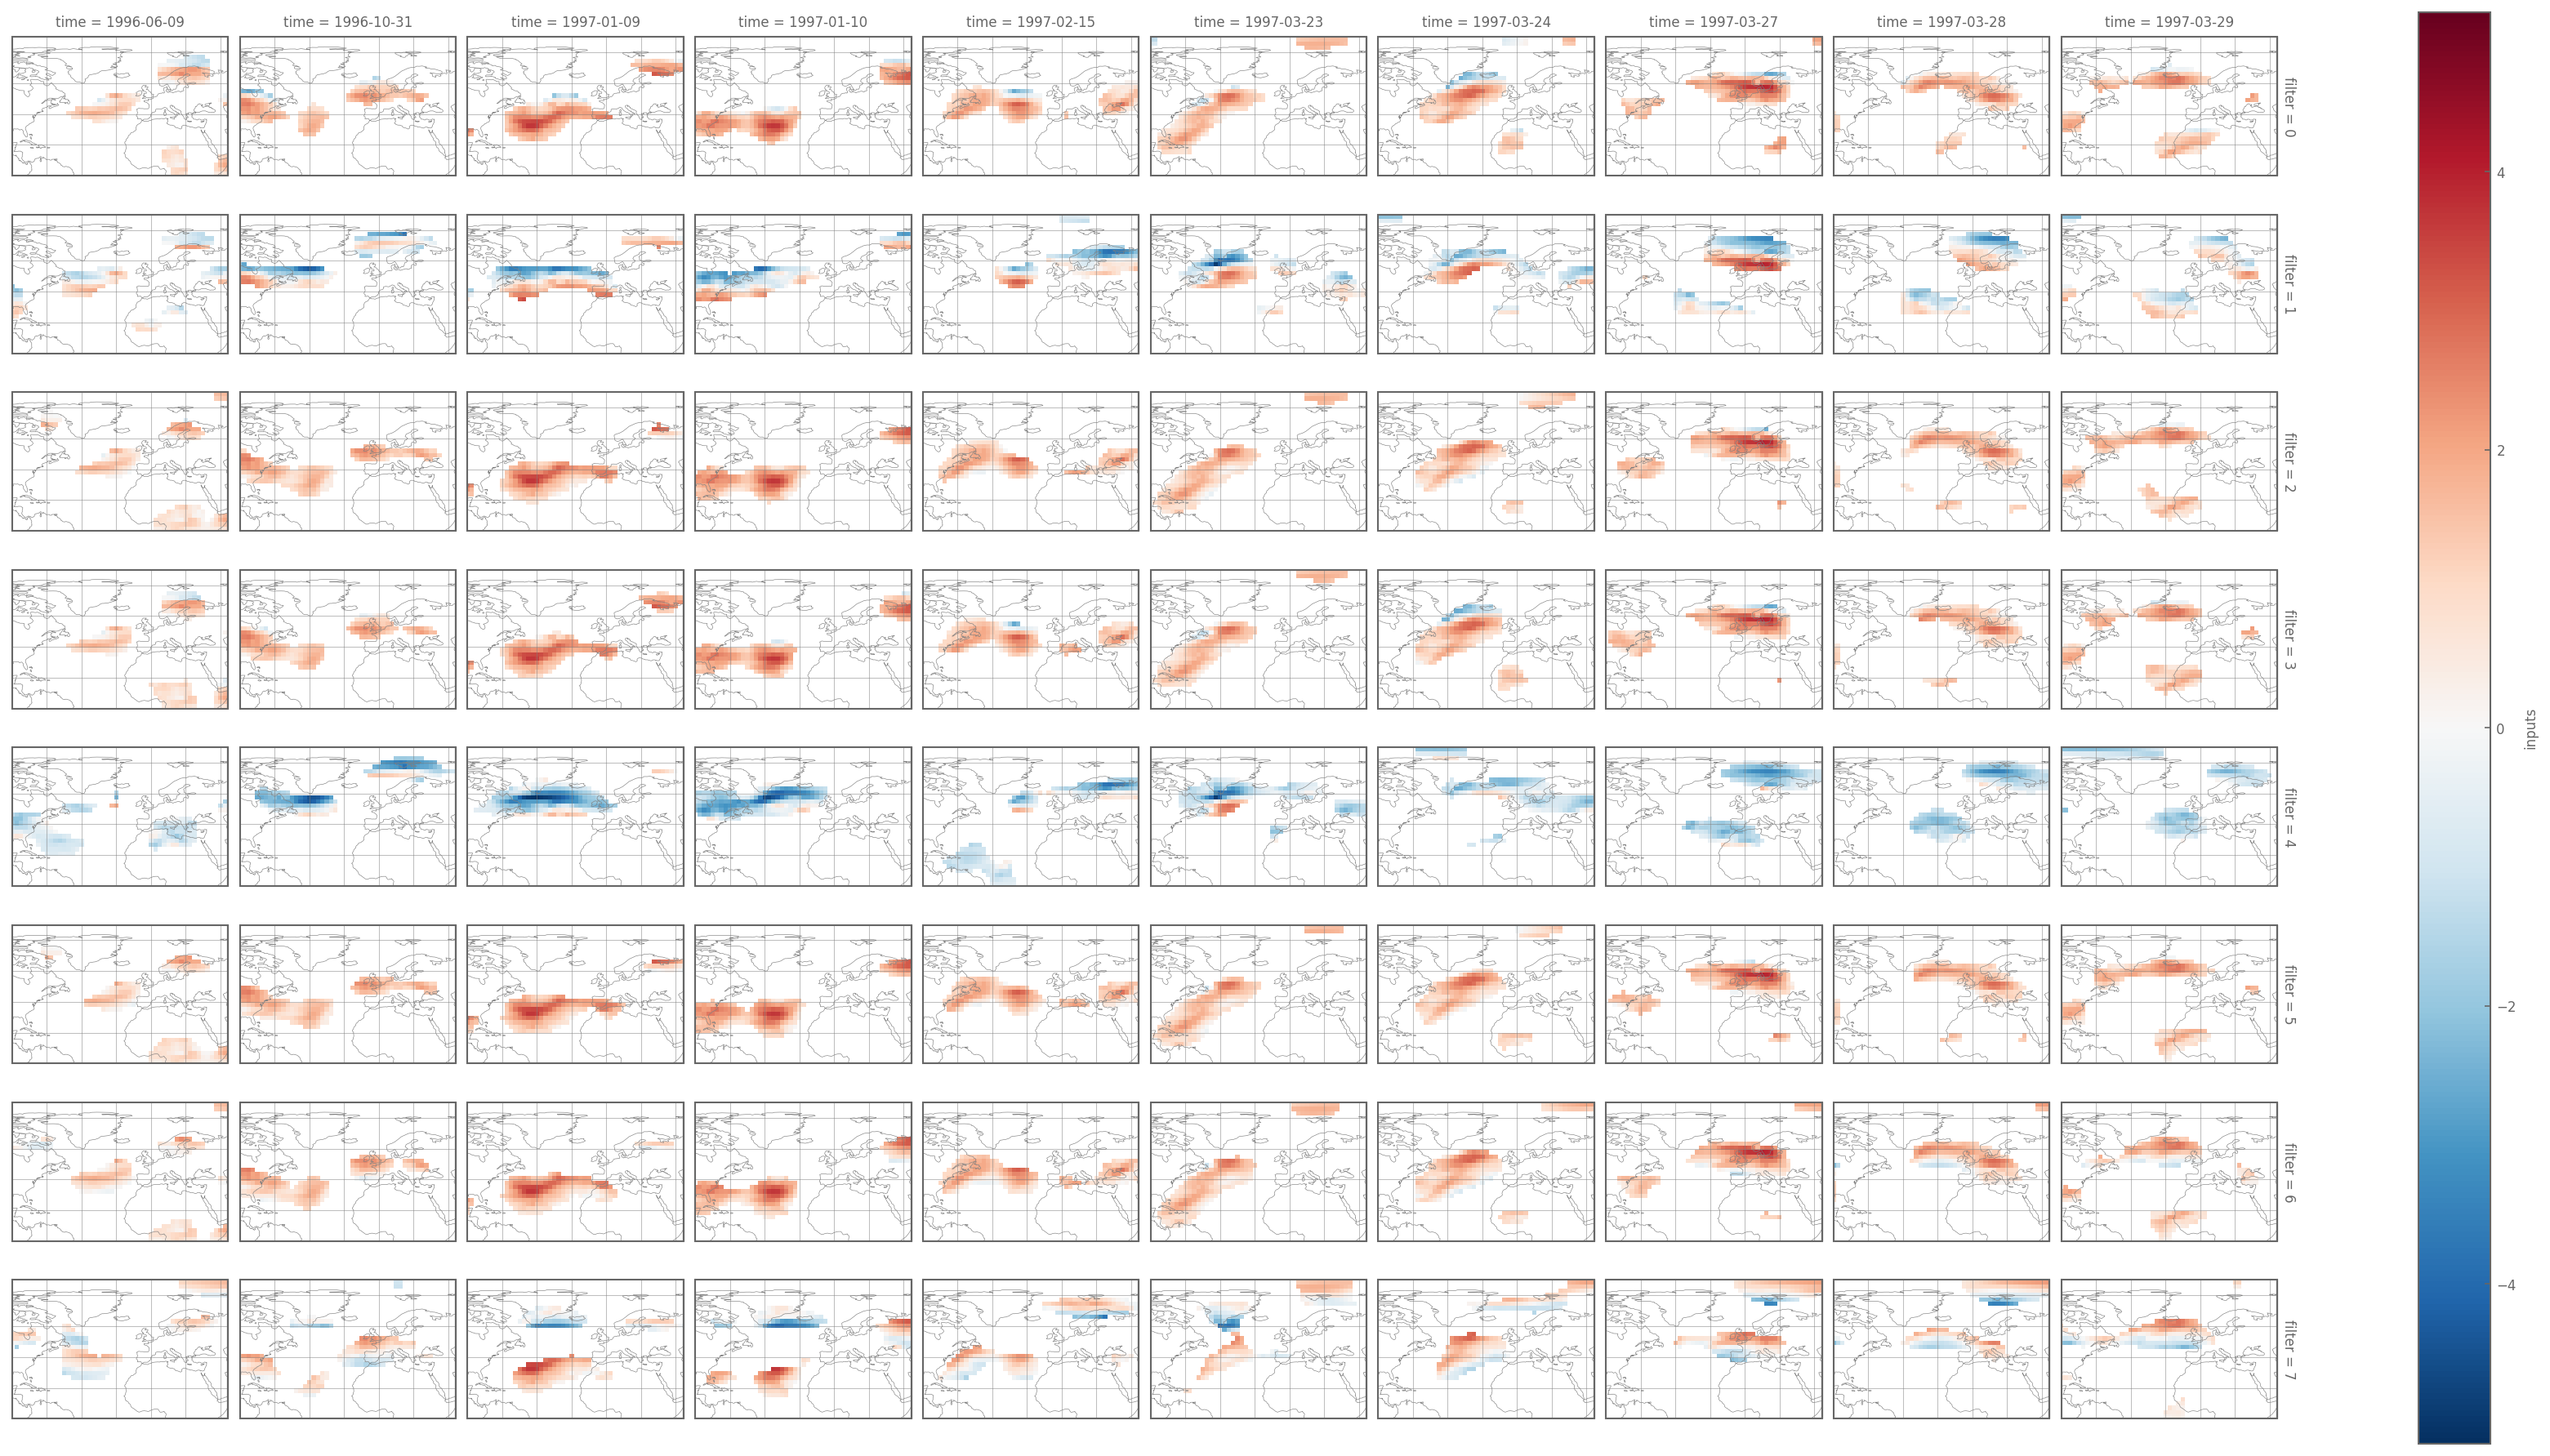

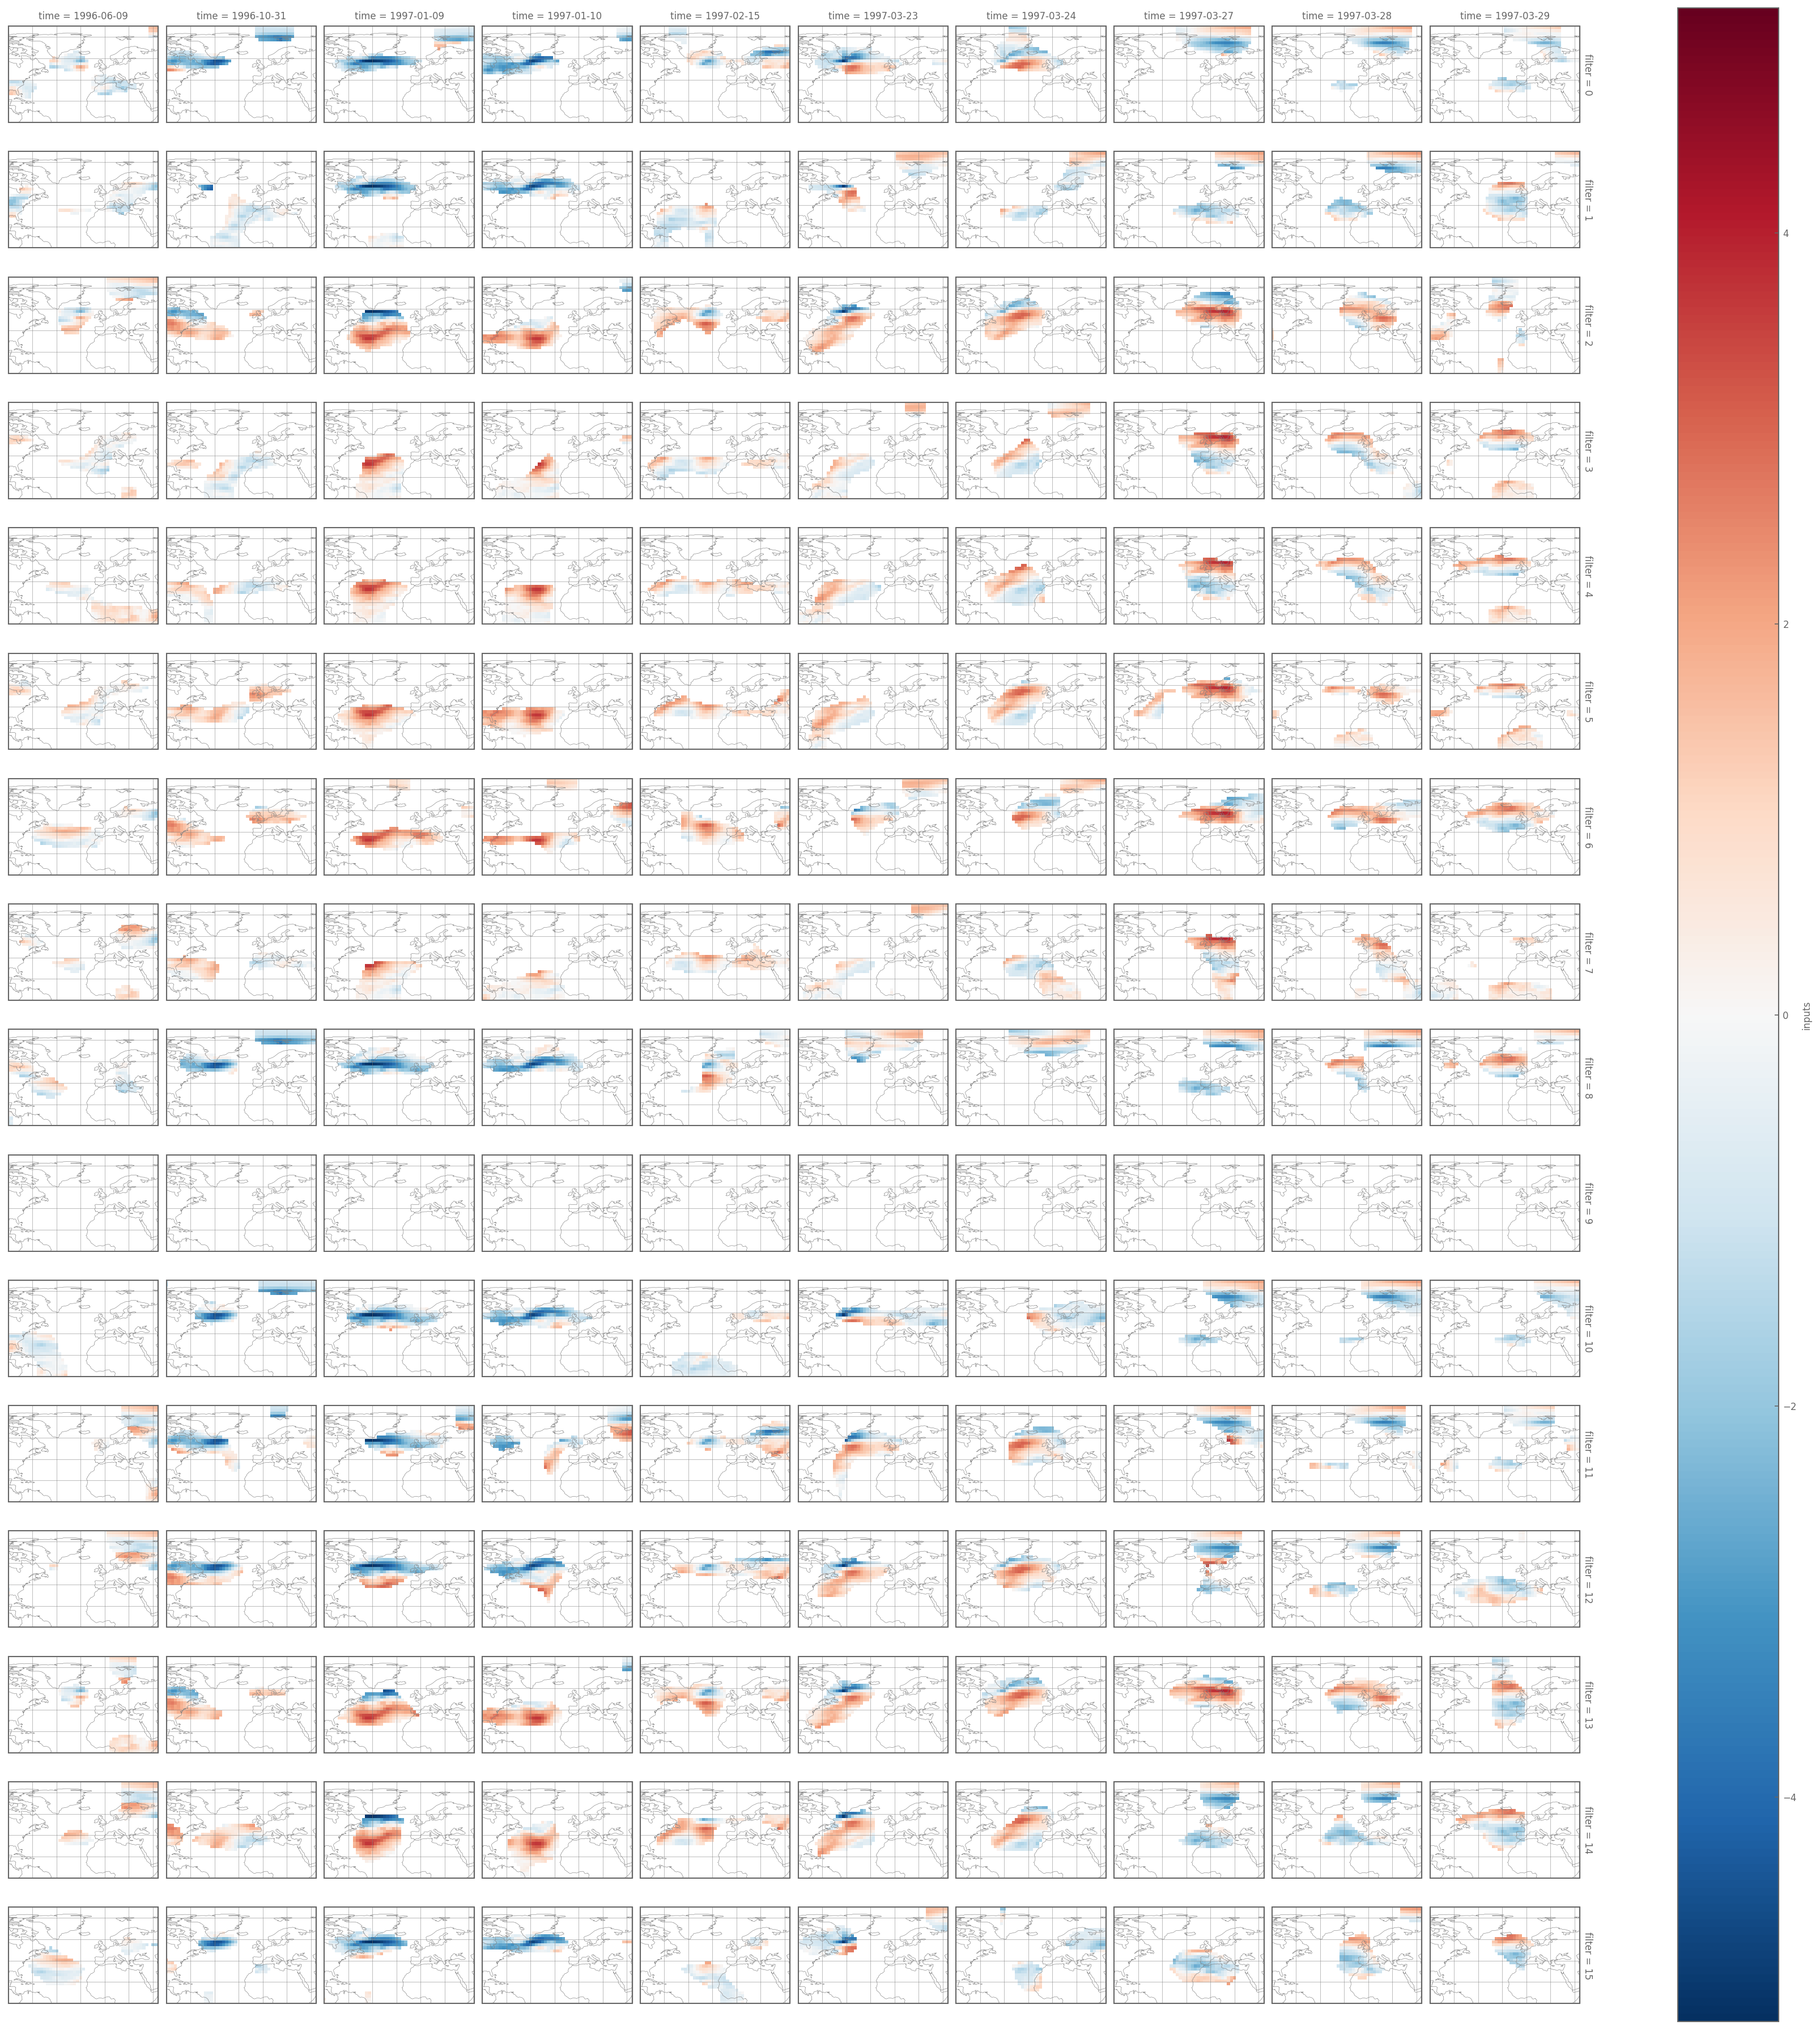

In [45]:
plot = data_in.plot(col='time', subplot_kws=dict(projection=ccrs.PlateCarree()), aspect=1.5,size=1.5)
for ax in plot.axs.flatten():
    clean_map_ax(ax)

plot = data_in.where(mask1).plot(row='filter', col='time', subplot_kws=dict(projection=ccrs.PlateCarree()), aspect=1.5,size=1.5)
for ax in plot.axs.flatten():
    clean_map_ax(ax)

plot = data_in.where(mask2).plot(row='filter', col='time', subplot_kws=dict(projection=ccrs.PlateCarree()), aspect=1.5,size=1.5)
for ax in plot.axs.flatten():
    clean_map_ax(ax)

plot = data_in.where(mask3).plot(row='filter', col='time', subplot_kws=dict(projection=ccrs.PlateCarree()), aspect=1.5,size=1.5)
for ax in plot.axs.flatten():
    clean_map_ax(ax)

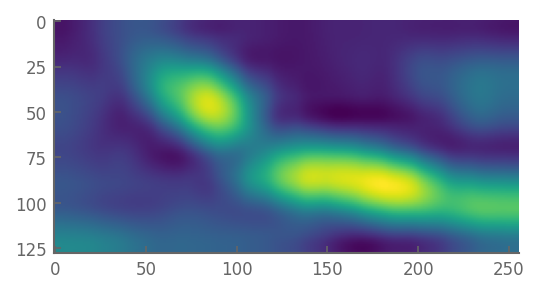

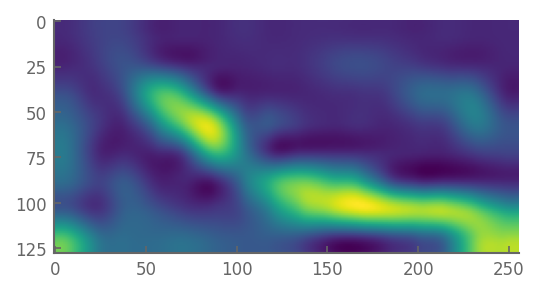

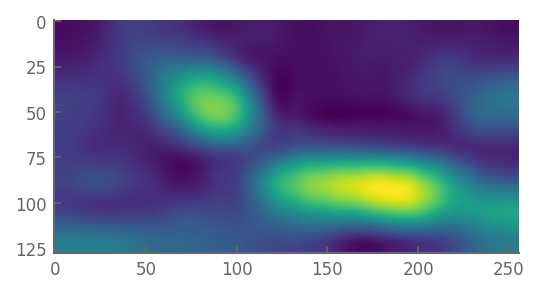

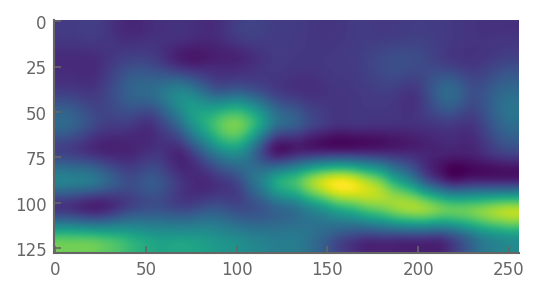

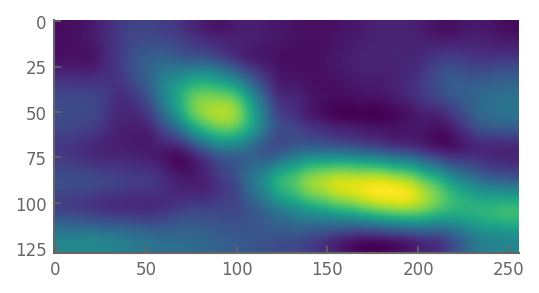

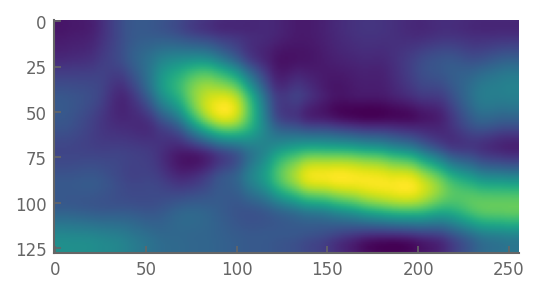

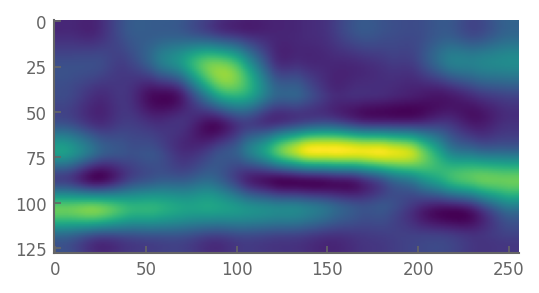

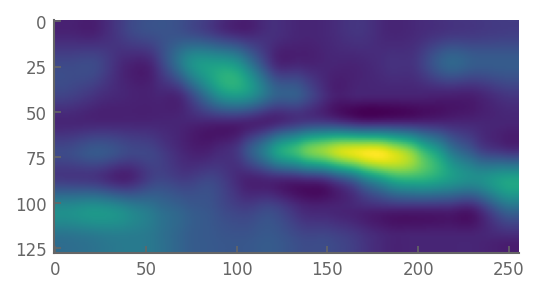

In [53]:
for k in range(8):
    plt.figure()
    plt.imshow(torch.nn.functional.interpolate(out23, scale_factor=16, mode='bicubic')[0][k].detach())

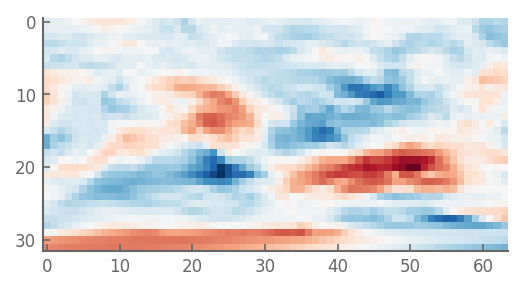

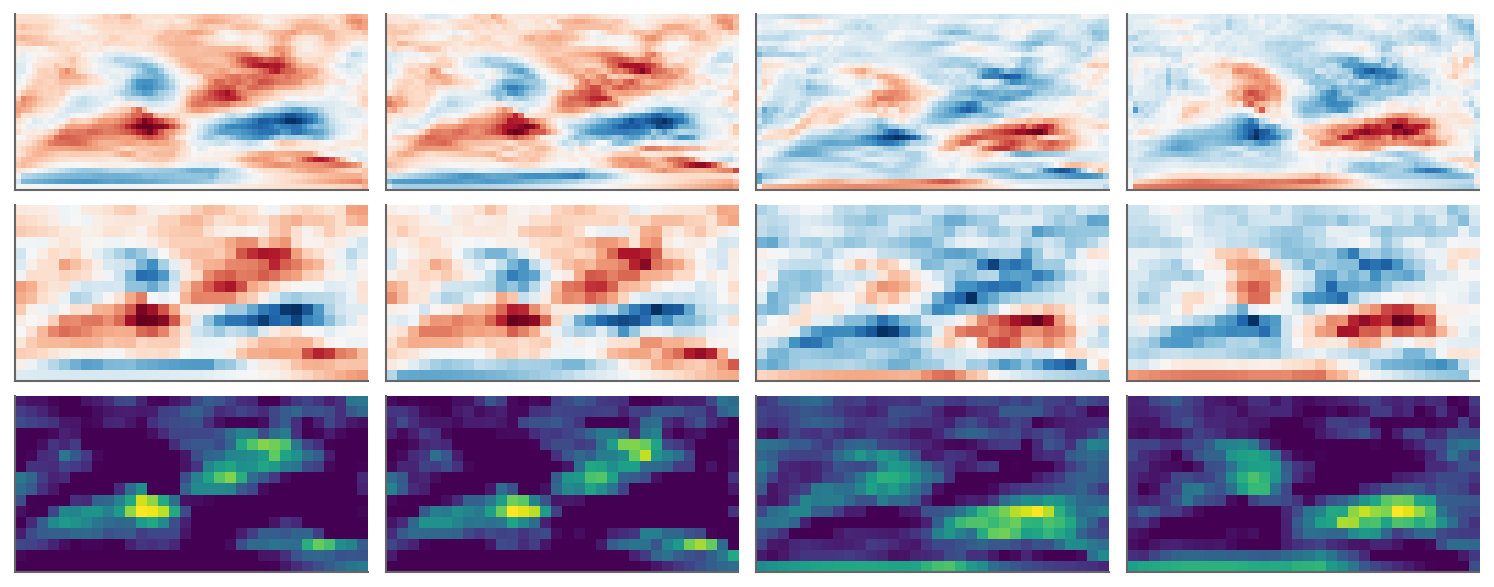

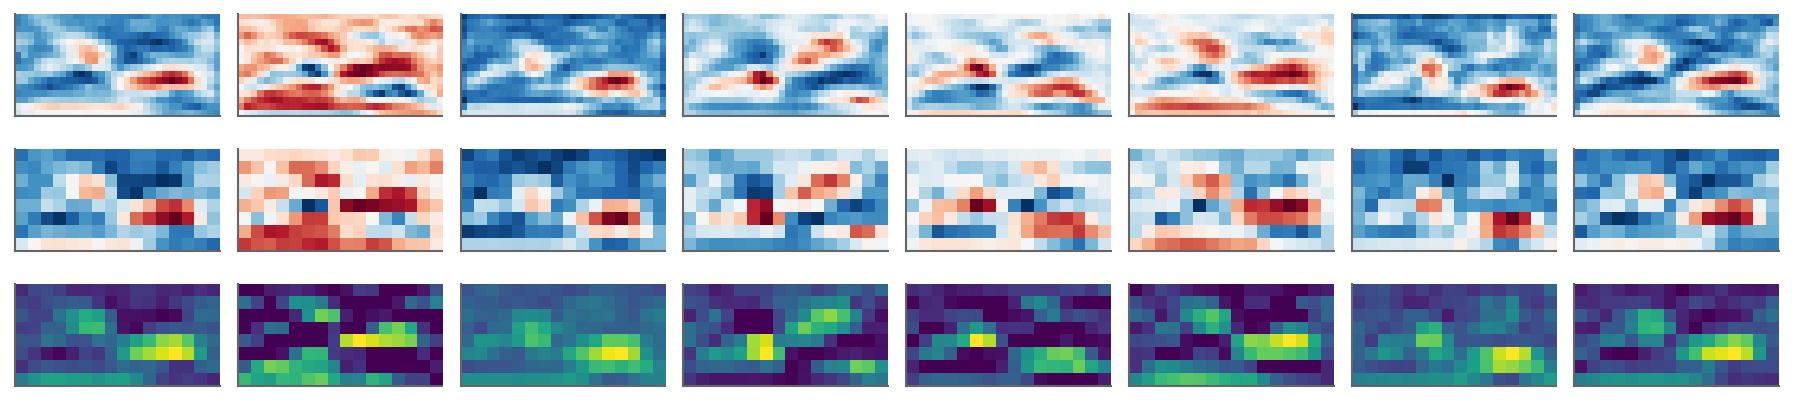

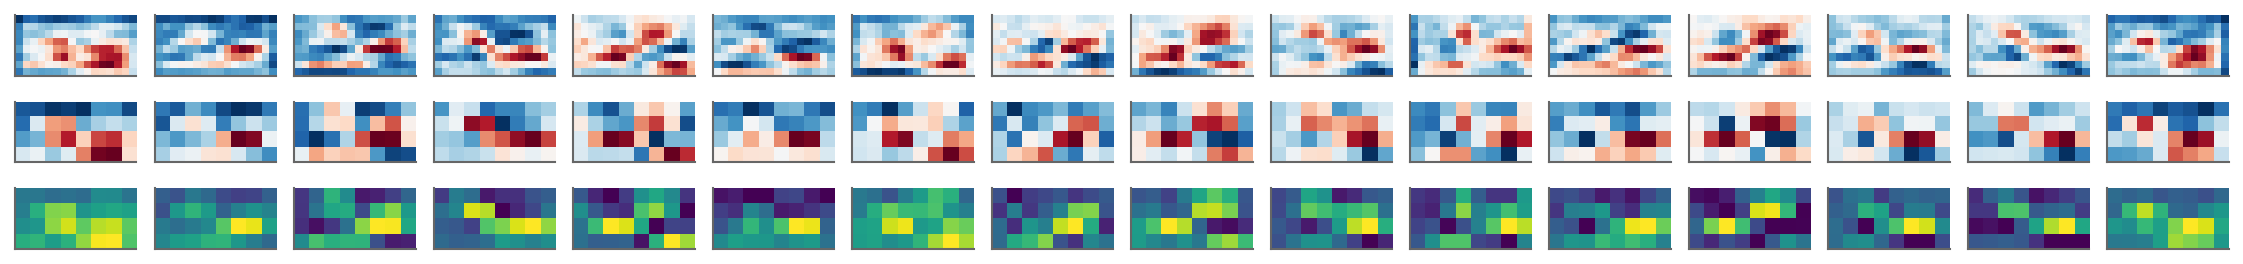

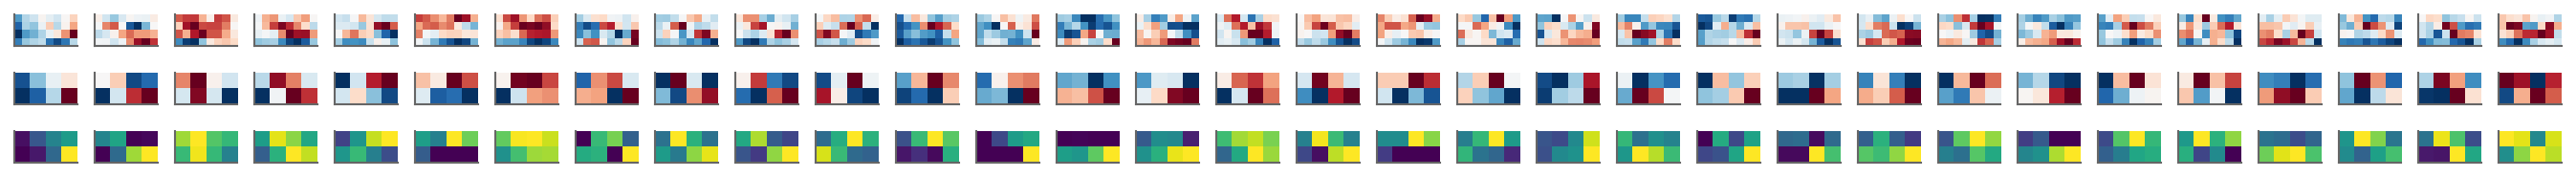

In [14]:
# test = train_loader.dataset[0][0][449]
test = train_loader.dataset[0][0][50]
test.shape

out11 = model.model.conv_layer1[0](test)
out12 = model.model.conv_layer1[1](out11)
out13 = model.model.conv_layer1[2](out12)

out21 = model.model.conv_layer2[0](out13)
out22 = model.model.conv_layer2[1](out21)
out23 = model.model.conv_layer2[2](out22)

out31 = model.model.conv_layer3[0](out23)
out32 = model.model.conv_layer3[1](out31)
out33 = model.model.conv_layer3[2](out32)

out41 = model.model.conv_layer4[0](out33)
out42 = model.model.conv_layer4[1](out41)
out43 = model.model.conv_layer4[2](out42)

fig, ax = plt.subplots()
ax.imshow(test[0], cmap='RdBu_r')

fig, axs = plt.subplots(3,4, figsize=(10,4))
for k in range(4):
    axs[0,k].imshow(out11[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out12[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out13[k].detach(), cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()

fig, axs = plt.subplots(3,8, figsize=(12,3))
for k in range(8):
    axs[0,k].imshow(out21[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out22[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out23[k].detach(),cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()

fig, axs = plt.subplots(3,16, figsize=(15,2))
for k in range(16):
    axs[0,k].imshow(out31[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out32[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out33[k].detach(), cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()

fig, axs = plt.subplots(3,32, figsize=(18,1.5))
for k in range(32):
    axs[0,k].imshow(out41[k].detach(), cmap='RdBu_r')
    axs[1,k].imshow(out42[k].detach(), cmap='RdBu_r')
    axs[2,k].imshow(out43[k].detach(), cmap='viridis', vmin=0)
for ax in axs.flatten():
    ax.set(title='', yticks=[], xticks=[])
plt.tight_layout()


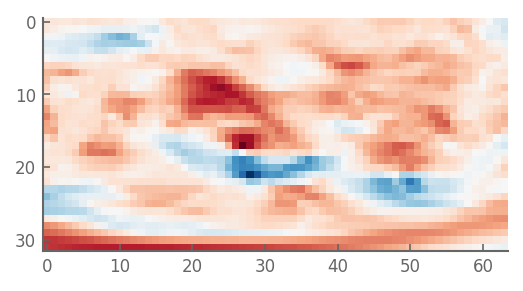

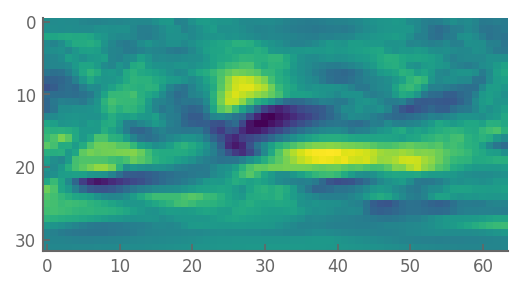

IndexError: index 4 is out of bounds for dimension 0 with size 4

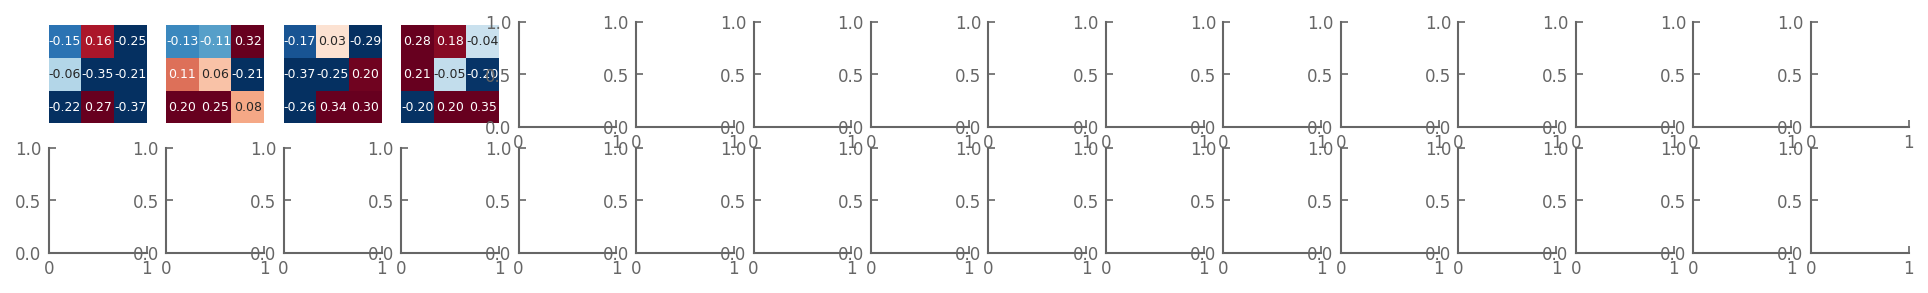

In [61]:
list_weights = []
for k in model.named_parameters():
    list_weights.append(k)
dic_weights = dict(list_weights)
# model.named_parameters()['model.conv_layer1.0.weight']
import itertools
weights_conv1 = dict(list_weights)['model.conv_layer1.0.weight']

fig, axs = plt.subplots(2,16, figsize=(16,2))
for line,row in itertools.product(range(2), range(16)):
    sns.heatmap(pd.DataFrame(weights_conv1[row,line].detach()), square=True, cmap='RdBu_r', vmin=-.2, vmax=.2, cbar=False, ax=axs[line,row], annot=True, fmt='.02f', annot_kws={"size": 6})
    axs[line,row].set(title='',ylabel='',xlabel='', yticks=[], xticks=[])
plt.tight_layout()

In [13]:
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        print(m.weights.data)

AttributeError: 'Conv2d' object has no attribute 'weights'

In [25]:
tensor_in.shape

torch.Size([5, 1, 32, 64])

In [27]:
events_predicted_all.shape

(4092,)

  0%|          | 0/91 [00:00<?, ?it/s]

KeyError: 'Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is not allowed.'

In [ ]:
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Polygon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker
def clean_map(plot, boundaries=(-90, 50, 0, 90)):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    lon_min, lon_max , lat_min, lat_max = boundaries
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        ax.set_extent(boundaries, crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='-')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(0,81,20))
        
        longitudes = np.linspace(lon_min, lon_max, 100)
        latitudes = np.linspace(lat_min, lat_max,100)
        xx = list(longitudes)[::-1]+\
                [longitudes.min() for _ in range(latitudes.size)] + \
                    list(longitudes)+\
                        [longitudes.max() for _ in range(latitudes.size)]
        yy = [latitudes.max() for _ in range(longitudes.size)] \
                + list(latitudes)[::-1]+\
                    [latitudes.min() for _ in range(longitudes.size)]+ \
                        list(latitudes)[::-1]
        verts = np.array([xx, yy]).T
        circle = Path(verts)
        ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

def clean_map_nocut(plot):
    projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
    for ax in plot.axs.flatten():
        ax.coastlines()
        # ax.set_extent((-60,60,0,80))
        # ax.set_extent([-90, 60, 20, 80], crs=ccrs.PlateCarree())
        
        # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                    linewidth=.5, color='gray', alpha=0.5, linestyle='--')
        gl.xlocator = mticker.FixedLocator(np.linspace(ds_test.longitude.min(),ds_test.longitude.max(),17)[:-1])
        gl.ylocator = mticker.FixedLocator(np.arange(20,81,20))
        
        # longitudes = np.linspace(-90, 60, 100)
        # latitudes = np.linspace(20,80,100)
        # xx = list(longitudes)[::-1]+\
        #         [longitudes.min() for _ in range(latitudes.size)] + \
        #             list(longitudes)+\
        #                 [longitudes.max() for _ in range(latitudes.size)]
        # yy = [latitudes.max() for _ in range(longitudes.size)] \
        #         + list(latitudes)[::-1]+\
        #             [latitudes.min() for _ in range(longitudes.size)]+ \
        #                 list(latitudes)[::-1]
        # verts = np.array([xx, yy]).T
        # circle = Path(verts)
        # ax.set_boundary(circle, transform=ccrs.PlateCarree())
        # break
    # ax.set_extent((-60,60,20,80), crs=ccrs.PlateCarree())
    

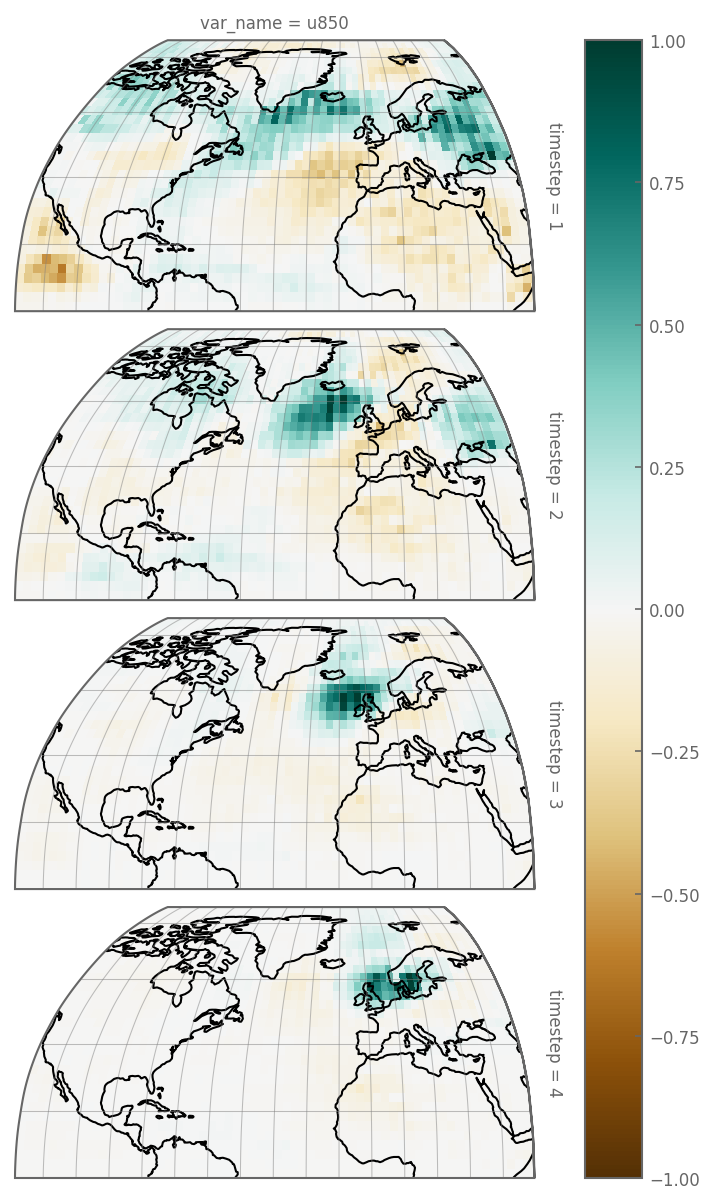

In [14]:

test = ds_attributions.mean('time')#.isel(time=5)#.coarsen(longitude=3,latitude=3,boundary='trim').sum()
test_max = test/test.max(['longitude','latitude', 'var_name'])
projection = ccrs.LambertConformal(central_longitude=-15.0, central_latitude=39.0)
projection = ccrs.Robinson(central_longitude=-15.0)

# test = test.where(test>0.01*test.max(['longitude','latitude','var_name']))
test = test.where(np.abs(test)>1e-3,0)
plot = test_max.plot(row='timestep', col='var_name', subplot_kws = dict(projection=projection), aspect=3, size=2, transform=ccrs.PlateCarree(),
                #  norm = matplotlib.colors.SymLogNorm(linthresh=0.002,linscale=.2), 
                 cmap='BrBG')

clean_map(plot, boundaries = (-125, 50, 0, 90))

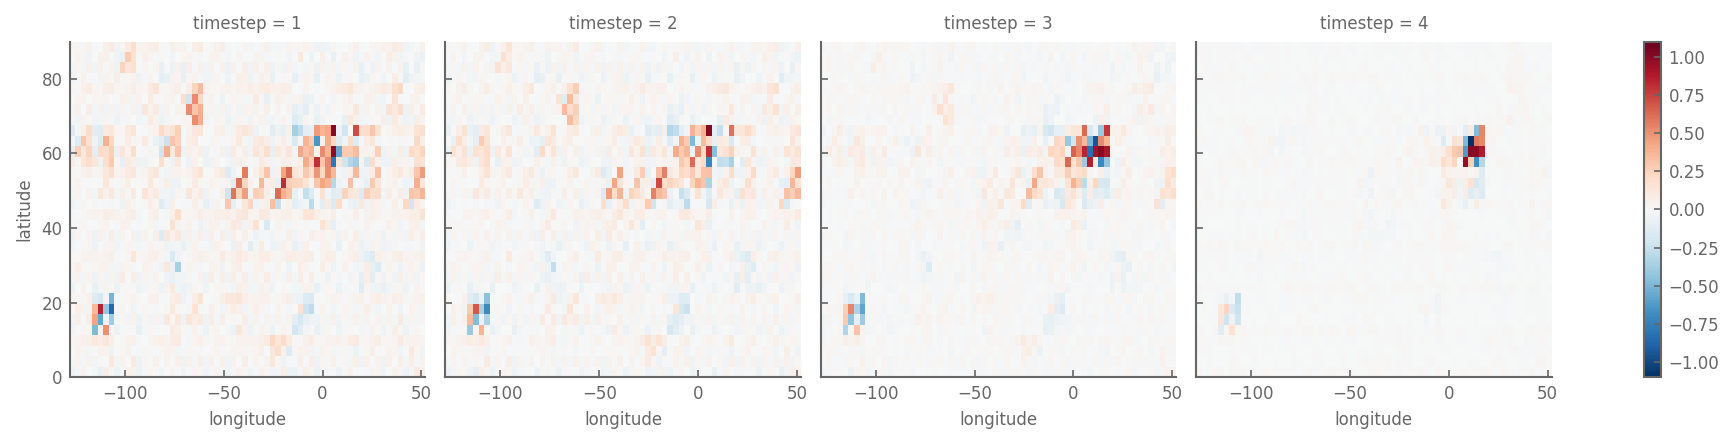

In [17]:
(ds_sens.mean('time')/ds_sens.mean('time').max(['longitude','latitude'])).plot(col='timestep')

In [13]:
final_ds = xr.Dataset(dict(attributions = ds_attributions, sensitivity=ds_sens))
# final_ds = final_ds.rename(time='attribution_time')
final_ds = xr.merge([final_ds, results.assign_coords(timestep=np.arange(1,5))])
n = wandb_logger.experiment.config['num_conv_layer']
# final_ds.to_netcdf(f'out_data/rosendal/u850_{n}conv_layer_attributions.nc')

NameError: name 'ds_attributions' is not defined

In [38]:
final_ds.to_netcdf('out_data/rosendal/4conv_layer_all_attributions.nc')
# final_ds.attributions.mean(['longitude','latitude']).plot()

In [20]:
# final_ds.to_netcdf('out_data/rosendal/4conv_layer_linus_style_attributions.nc')
final_ds.to_netcdf('out_data/rosendal/ViT_patch4_attributions.nc')